# Module 2: Classical ML Baseline

In [1]:
import numpy as np
import pandas as pd

# load 1-hot encoded promoter file from file (2d array)
result = np.loadtxt("data/promoters.1hot.csv", delimiter=",")
#print(result.shape)

# load dataframe with metadata
df = pd.read_csv("data/promoter_by_expression.csv")
print(df.head())

y = df['label'].values
print(f"X shape: {result.shape}")
print(f"y shape: {y.shape}")
print(f"Class balance: {y.mean():.2f} positive rate")

     gene_id                                           sequence  label  \
0  gene_0000  GTCGACGGATTCGCTATACGGTCCGATAAGTATAAAATAGTCGTCG...      1   
1  gene_0001  CTAAAAGATGTAGGGAACTATGCACATGAATATAAAGAACGATTCT...      1   
2  gene_0002  GACCACACGGACAAAGACGAAATGACAGCGTATAAAGGCAGAAGCT...      1   
3  gene_0003  GCGCAGTTGCCAGGTAAGTCTCTGATGCCATATAAACGGAAGCATG...      1   
4  gene_0004  AAGATCAACTACCTGAATAGCATACATTTGTATAAAAGTTACTGAC...      1   

   gc_content  tata_present  sequence_length  
0       0.375             1              200  
1       0.355             1              200  
2       0.380             1              200  
3       0.365             1              200  
4       0.345             1              200  
X shape: (1000, 800)
y shape: (1000,)
Class balance: 0.50 positive rate


In [5]:
# Generate test/train split

from sklearn.model_selection import train_test_split


# random state is the seed
# test size is proportion taken for testing
X_train, X_test, y_train, y_test = train_test_split(
    result, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (800, 800)
Test set:     (200, 800)


# Interesting way to think about logistic regression (As compared to linear regression)

![regression types](assets/regression_types.png)

In [ ]:
# model number 1: logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# step 0: understand the data structure
# X_train: 800 sequences of 200bp (4 bits per base) stored as an 2D np array
# X_test: 200 sequences of 200bp (4 bits per base) stored as an 2D np array
# y_train: A 1d np array of the df['label'] column (length 800, matched to X_train). 1 = high exp, 0 = low exp. (ground truth)
# y_test: A 1d np array of the df['label'] column (length 200, matched to X_test). 1 = high exp, 0 = low exp. (ground truth)

# Step 1: create a LogisticRegression model object
model = LogisticRegression(random_state=42)

#print(model) # = LogisticRegression(random_state=42)
# Step 2: train it on the training data
model.fit(X_train, y_train)

# Step 3: generate predictions on the test set
y_pred = model.predict(X_test)
# print(y_pred) # A 1d np array (length 200) of prediction based off of X_test array. 1 = predicted high exp, 0 = predicted low expS


print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}")

[[9.97574470e-01 2.42552967e-03]
 [7.72617989e-01 2.27382011e-01]
 [9.99933560e-01 6.64404005e-05]
 [9.98892217e-01 1.10778291e-03]
 [1.10237038e-02 9.88976296e-01]]
Test accuracy: 0.895


      P_low    P_high  pred  ans  tata
0  0.997574  0.002426     0    0     1
1  0.772618  0.227382     0    0     1
2  0.999934  0.000066     0    0     1
3  0.998892  0.001108     0    0     1
4  0.011024  0.988976     1    1     1
(200, 2)


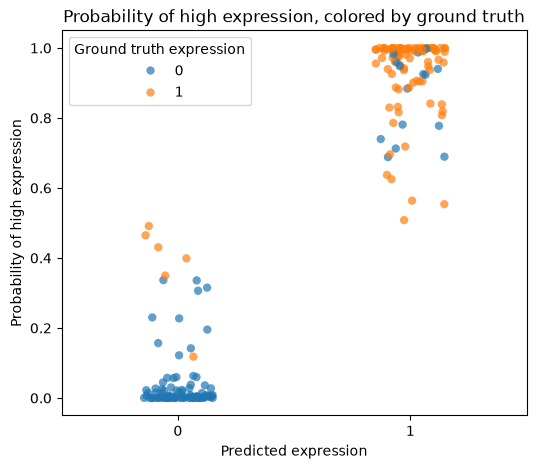

In [ ]:
# Some misc. graphing
import matplotlib.pyplot as plt
import seaborn as sns

y_proba = model.predict_proba(X_test)
# print(y_proba[:5])
prob_df = pd.DataFrame(y_proba, columns=['P_low', 'P_high'])
prob_df['pred'] = y_pred
prob_df['ans'] = y_test
print(prob_df.head())
print(y_proba.shape)

# plot
plt.figure(figsize = (6, 5))
sns.stripplot(
    data = prob_df,
    x='pred',
    y='P_high',
    jitter=0.15,
    alpha = 0.7,
    size=6,
    hue='tata_'
)

plt.title("Probability of high expression, colored by ground truth")
plt.xlabel("Predicted expression")
plt.ylabel("Probability of high expression")
plt.legend(title="Ground truth expression")

# Maybe the high confidence false positives are "low" promoters that had a TATA box sythesized due to randomness?

In [39]:
# Further interogation of model 1 performance
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.86      0.89       104
           1       0.86      0.94      0.90        96

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.89       200
weighted avg       0.90      0.90      0.89       200



ROC-AUC: 0.957


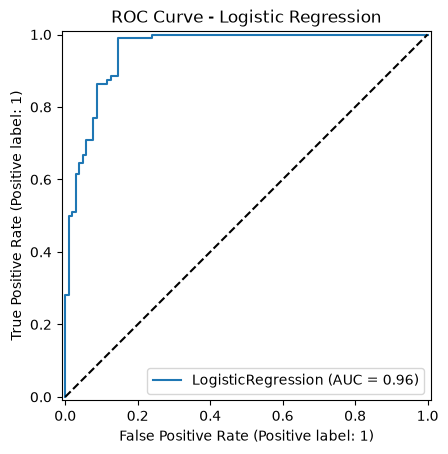

In [40]:
# ROC-AUC
from sklearn.metrics import roc_auc_score, RocCurveDisplay

auc = roc_auc_score(y_test, y_proba[:, 1])
print(f"ROC-AUC: {auc:.3f}")

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.title("ROC Curve - Logistic Regression")
plt.show()